# 01 GBDT training

# 02 CV result

In [13]:
import os
import pandas as pd

# 让 pandas 打印时不截断长文本
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

for type in ['nor','ext','hr']:
    work_folder = r'E:\seoul\480_based\Machine Learning'
    folder = os.path.join(work_folder, rf'0_9394_GBDT_{type}_2016_cv_results_120m.xlsx')

    file = pd.read_excel(folder)

    # 找到 rank_test_score 最小值
    min_value = file['rank_test_score'].min()

    # 打印最小值所在行
    min_row = file.loc[file['rank_test_score'] == min_value]
    print(type)
    print(min_row['mean_test_score'])
    print(min_row['params'])


nor
157    0.938224
Name: mean_test_score, dtype: float64
157    {'learning_rate': 0.023732950058719497, 'max_depth': 8, 'max_features': 0.47351811621687767, 'min_samples_split': 2, 'n_estimators': 4168, 'subsample': 0.7574937629823866}
Name: params, dtype: object
ext
157    0.961281
Name: mean_test_score, dtype: float64
157    {'learning_rate': 0.023732950058719497, 'max_depth': 8, 'max_features': 0.47351811621687767, 'min_samples_split': 2, 'n_estimators': 4168, 'subsample': 0.7574937629823866}
Name: params, dtype: object
hr
157    0.953895
Name: mean_test_score, dtype: float64
157    {'learning_rate': 0.023732950058719497, 'max_depth': 8, 'max_features': 0.47351811621687767, 'min_samples_split': 2, 'n_estimators': 4168, 'subsample': 0.7574937629823866}
Name: params, dtype: object


In [17]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import re
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# === 基本设置 ===
grid_folder = r'E:\seoul\480_based'
ml_folder = os.path.join(grid_folder, 'Machine Learning')

# 用20个 random seeds
np.random.seed(0)
random_seeds = np.random.choice(10000, size=20, replace=False)

def run_gbdt_with_best_params(grid_folder, ml_folder, year=2016, n=0, r=9394, grid='240m'):
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR',
                        'Dist_W', 'Dist_P', 'Dist_M', 'X', 'Y']
    
    results = []

    # === 主循环 ===
    for target in target_vars:
        short_target = target.split('_')[0]  # 'nor'/'ext'/'hr'

        # 读取对应的cv结果文件，提取最佳参数
        cv_file = os.path.join(ml_folder, f"{n}_{r}_GBDT_{short_target}_{year}_cv_results_{grid}.xlsx")
        if not os.path.exists(cv_file):
            print(f"[⚠️ File not found] {cv_file}")
            continue

        df_cv = pd.read_excel(cv_file)
        if 'rank_test_score' not in df_cv.columns:
            print(f"[⚠️ rank_test_score missing] {cv_file}")
            continue

        best_row = df_cv.loc[df_cv['rank_test_score'].idxmin()]
        param_cols = [c for c in df_cv.columns if c.startswith('param_')]
        best_params = {c.replace('param_', ''): best_row[c] for c in param_cols}
        print(f"[✅ Loaded best params for {short_target}] {best_params}")

        # === 加载 shapefile ===
        pattern = f"city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp"
        input_path = None
        for filename in os.listdir(grid_folder):
            if filename.endswith(pattern):
                input_path = os.path.join(grid_folder, filename)
                break
        if not input_path:
            print(f"[⚠️ Shapefile not found for {year}]")
            continue

        gdf = gpd.read_file(input_path)
        gdf_clean = gdf.replace([np.inf, -np.inf], np.nan).dropna(subset=[target] + explanatory_vars)
        X = gdf_clean[explanatory_vars]
        y = gdf_clean[target]

        # === 使用相同随机种子重新划分数据 ===
        seed = random_seeds[n]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

        # === 用最佳参数重新训练模型 ===
        gbdt = GradientBoostingRegressor(random_state=0, **best_params)
        gbdt.fit(X_train, y_train)

        # === 预测与评估 ===
        y_train_pred = gbdt.predict(X_train)
        y_test_pred = gbdt.predict(X_test)

        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

        print(f"{short_target.upper()} | Train R²={r2_train:.3f}, Test R²={r2_test:.3f}")

        # === ✅ 补上 feature importance 提取 ===
        feature_importances = gbdt.feature_importances_
        for var, importance in zip(explanatory_vars, feature_importances):
            results.append({
                'Feature': var,
                'FeatureImportance_TrainModel': round(importance, 4),
                'Target': target,
                'Train_R2': round(r2_train, 4),
                'Test_R2': round(r2_test, 4),
                'Train_RMSE': round(rmse_train, 4),
                'Test_RMSE': round(rmse_test, 4),
                **best_params
            })

    # === 保存结果 ===
    df_results = pd.DataFrame(results)
    save_path = os.path.join(ml_folder, f"{year}_R2_Comparison_Retrained_{n}_{r}_{grid}.xlsx")
    df_results.to_excel(save_path, index=False)
    print(f"\n✅ Saved retrained R² comparison -> {save_path}")
    return df_results


# === 调用 ===
run_gbdt_with_best_params(grid_folder, ml_folder, year=2016, n=0, r=9394, grid='120m')


[✅ Loaded best params for nor] {'learning_rate': 0.0237329500587195, 'max_depth': 8, 'max_features': 0.4735181162168777, 'min_samples_split': 2, 'n_estimators': 4168, 'subsample': 0.7574937629823866}
NOR | Train R²=1.000, Test R²=0.924
[✅ Loaded best params for ext] {'learning_rate': 0.0237329500587195, 'max_depth': 8, 'max_features': 0.4735181162168777, 'min_samples_split': 2, 'n_estimators': 4168, 'subsample': 0.7574937629823866}
EXT | Train R²=1.000, Test R²=0.946
[✅ Loaded best params for hr] {'learning_rate': 0.0237329500587195, 'max_depth': 8, 'max_features': 0.4735181162168777, 'min_samples_split': 2, 'n_estimators': 4168, 'subsample': 0.7574937629823866}
HR | Train R²=1.000, Test R²=0.927

✅ Saved retrained R² comparison -> E:\seoul\480_based\Machine Learning\2016_R2_Comparison_Retrained_0_9394_120m.xlsx


,Feature,FeatureImportance_TrainModel,Target,Train_R2,Test_R2,Train_RMSE,Test_RMSE,learning_rate,max_depth,max_features,min_samples_split,n_estimators,subsample
0,BCR,0.2619,nor_2016,1.0,0.9242,0.0,0.6629,0.023733,8,0.473518,2,4168,0.757494
1,BHV,0.1223,nor_2016,1.0,0.9242,0.0,0.6629,0.023733,8,0.473518,2,4168,0.757494
2,SVF,0.0568,nor_2016,1.0,0.9242,0.0,0.6629,0.023733,8,0.473518,2,4168,0.757494
3,NDVI,0.1877,nor_2016,1.0,0.9242,0.0,0.6629,0.023733,8,0.473518,2,4168,0.757494
4,EV,0.0838,nor_2016,1.0,0.9242,0.0,0.6629,0.023733,8,0.473518,2,4168,0.757494
5,WR,0.1133,nor_2016,1.0,0.9242,0.0,0.6629,0.023733,8,0.473518,2,4168,0.757494
6,Dist_W,0.0240,nor_2016,1.0,0.9242,0.0,0.6629,0.023733,8,0.473518,2,4168,0.757494
7,Dist_P,0.0202,nor_2016,1.0,0.9242,0.0,0.6629,0.023733,8,0.473518,2,4168,0.757494
8,Dist_M,0.0490,nor_2016,1.0,0.9242,0.0,0.6629,0.023733,8,0.473518,2,4168,0.757494
9,X,0.0568,nor_2016,1.0,0.9242,0.0,0.6629,0.023733,8,0.473518,2,4168,0.757494


In [ ]:
import os
import pandas as pd
work_folder = r'E:\seoul\480_based\Machine Learning'
folder = os.path.join(work_folder, r'2016_R2_Comparison_Retrained_0_9394_120m.xlsx')
file = pd.read_excel(folder)
file

,Feature,FeatureImportance_TrainModel,Target,Train_R2,Test_R2,Train_RMSE,Test_RMSE,learning_rate,max_depth,max_features,min_samples_split,n_estimators,subsample
0,BCR,0.2619,nor,1,0.9242,0,0.6629,0.023733,8,0.473518,2,4168,0.757494
1,BHV,0.1223,nor,1,0.9242,0,0.6629,0.023733,8,0.473518,2,4168,0.757494
2,SVF,0.0568,nor,1,0.9242,0,0.6629,0.023733,8,0.473518,2,4168,0.757494
3,NDVI,0.1877,nor,1,0.9242,0,0.6629,0.023733,8,0.473518,2,4168,0.757494
4,EV,0.0838,nor,1,0.9242,0,0.6629,0.023733,8,0.473518,2,4168,0.757494
5,WR,0.1133,nor,1,0.9242,0,0.6629,0.023733,8,0.473518,2,4168,0.757494
6,Dist_W,0.0240,nor,1,0.9242,0,0.6629,0.023733,8,0.473518,2,4168,0.757494
7,Dist_P,0.0202,nor,1,0.9242,0,0.6629,0.023733,8,0.473518,2,4168,0.757494
8,Dist_M,0.0490,nor,1,0.9242,0,0.6629,0.023733,8,0.473518,2,4168,0.757494
9,X,0.0568,nor,1,0.9242,0,0.6629,0.023733,8,0.473518,2,4168,0.757494


# feature importance 出图

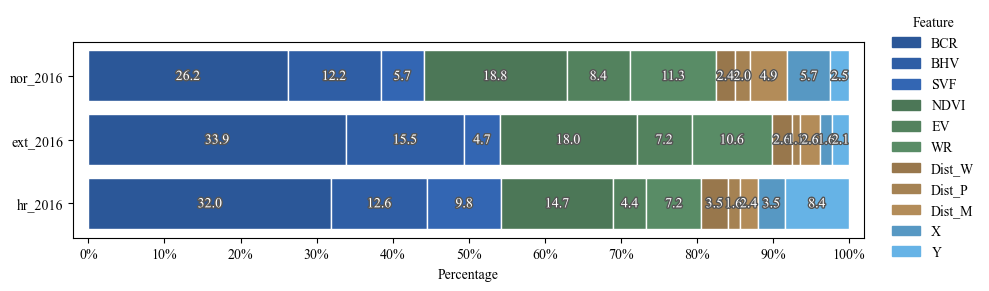

Saved to: E:\seoul\480_based\Machine Learning\2016_final_GBDT_feature_importance_stacked_120m.png


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb

# 设置全局字体为 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 读数据
path = r"E:\seoul\480_based\Machine Learning\2016_R2_Comparison_Retrained_0_9394_120m.xlsx"
df = pd.read_excel(path)

# pivot：每行一个 Target，每列一个 Feature
pivot = df.pivot_table(index='Target', columns='Feature', 
                       values='FeatureImportance_TrainModel', aggfunc='sum').fillna(0)


# 手动调整 Target 的行顺序
row_order = ['hr_2016', 'ext_2016','nor_2016']
pivot = pivot.reindex(row_order)

# 指定 Feature 顺序
explanatory_vars_gbdt = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 
                         'Dist_W', 'Dist_P', 'Dist_M', 'X', 'Y']


# 四组特征
groups = {
    'group1': ['BCR', 'BHV', 'SVF'],          # 湖蓝系
    'group2': ['NDVI', 'EV', 'WR'],           # 藏蓝系
    'group3': ['Dist_W', 'Dist_P', 'Dist_M'], # 棕色系
    'group4': ['X', 'Y']                      # 墨绿色系
}

base_colors = {
    'group4': np.array([0.4, 0.7, 0.9]),   # 柔和湖蓝
    'group1': np.array([0.2, 0.4, 0.7]),   # 深藏蓝
    'group2': np.array([0.35, 0.55, 0.4]), # 墨绿色
    'group3': np.array([0.7, 0.55, 0.35])# 高级咖啡棕}
 } 
# 生成组内渐变色（浅→深）
def generate_gradient_colors(features, base_rgb):
    n = len(features)
    colors = []
    for i in range(n):
        factor = 0.85 + 0.15*(i/(n-1))  # 浅→深
        colors.append(base_rgb * factor)
    return dict(zip(features, colors))

color_map = {}
for gname, feats in groups.items():
    color_map.update(generate_gradient_colors(feats, base_colors[gname]))

# 绘图
fig, ax = plt.subplots(figsize=(10, max(3, 0.8 * len(pivot))))
bottom = np.zeros(len(pivot))
# 绘图前设置 X 轴范围和刻度
ax.set_xlim(-0.02, 1.02)  # 超过 1 点点空间

# 设置 X 轴刻度为百分比
ax.set_xticks(np.linspace(0, 1, 11))  # 0,0.1,...,1
ax.set_xticklabels([f"{int(x*100)}%" for x in np.linspace(0, 1, 11)])

for feature in explanatory_vars_gbdt:
    vals = pivot[feature].values
    ax.barh(pivot.index, vals, left=bottom, color=color_map[feature], edgecolor='white')
    for i, val in enumerate(vals):
        txt = ax.text(
            bottom[i] + val/2, i, f"{val*100:.1f}", 
            va='center', ha='center', fontsize=10, color="white"
        )
        # 给文字加描边
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='#555555'),  # 描边颜色
            path_effects.Normal()  # 正常文字显示
        ])
    bottom += vals

# legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[feature]) for feature in explanatory_vars_gbdt]
ax.legend(handles, explanatory_vars_gbdt, bbox_to_anchor=(1.02, 1.2), loc='upper left', title='Feature', frameon=False)

ax.set_xlabel("Percentage")

plt.tight_layout()
# 保存到本地（示例）
out_file = r"E:\seoul\480_based\Machine Learning\2016_final_GBDT_feature_importance_stacked_120m.png"
fig.savefig(out_file, dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("Saved to:", out_file)

# ext+nor self

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\2016_R2_Comparison_Retrained_0_9394_120m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params_120m.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)
    best_df_sdem = best_df_sdem[best_df_sdem['Model']=='SDEM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[1:]:

        # 先收集 EXT 和 NOR 的预测数据
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            output_path = os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison_120m.png')
            
            # # 👉 如果文件已存在且大小大于 10KB，就跳过
            # if os.path.exists(output_path) and os.path.getsize(output_path) > 10 * 1024:
            #     print(f"⏩ 跳过 {feature}_ext_nor_{year}_comparison_120m.png（已存在）")
            #     continue

            plt.figure(figsize=(8,5))
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = random_seeds[0])
                # ----------- PDP 计算部分 -----------
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])

                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                    
                y_sdem_pred = np.array(y_sdem_pred)

                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdem = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdem = '#0000ff'  # 蓝色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名
                # if target.lower().startswith('nor'):
                #     # 绘图
                #     for x in X[feature]:
                #         plt.axvline(x=x, color='gray', alpha=0.1, linewidth=0.1)
                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')


            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.margins(x=0)  # 去掉x方向留白
             
             
             
            plt.ylim(20,55)
            plt.tight_layout()
            plt.savefig(output_path, dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison_120m.png")

c:\Users\JUJUBE\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


['nor_2016' 'ext_2016' 'hr_2016']


KeyboardInterrupt: 

<Figure size 800x500 with 0 Axes>

# hr self

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\2016_R2_Comparison_Retrained_0_9394_120m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params_120m.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)
    best_df_sdem = best_df_sdem[best_df_sdem['Model']=='SDEM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = random_seeds[0])
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

                # ----------- PDP 计算部分 -----------
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)


                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)


                color_gbdt = '#333333'  # 黑色
                color_sdem = '#555555'  # 黑色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2023': 'Nor_LST',
                    'ext_2023': 'Ext_LST',
                    'hr_2023': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名
                # # 绘图
                # for x in X[feature]:
                #     plt.axvline(x=x, color='gray', alpha=0.1, linewidth=0.1)
                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')


            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.margins(x=0)  # 去掉x方向留白
             
             
             
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison_120m.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison_120m.png")


['nor_2016' 'ext_2016' 'hr_2016']


E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  warnings.warn(message)


✅ Saved BCR_hr_2016_comparison_240m.png


E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  warnings.warn(message)


✅ Saved BHV_hr_2016_comparison_240m.png


...

✅ Saved Dist_W_hr_2016_comparison_240m.png


E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  warnings.warn(message)


✅ Saved Dist_P_hr_2016_comparison_240m.png


E:\python\lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
E:\python\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  warnings.warn(message)


✅ Saved Dist_M_hr_2016_comparison_240m.png
